# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

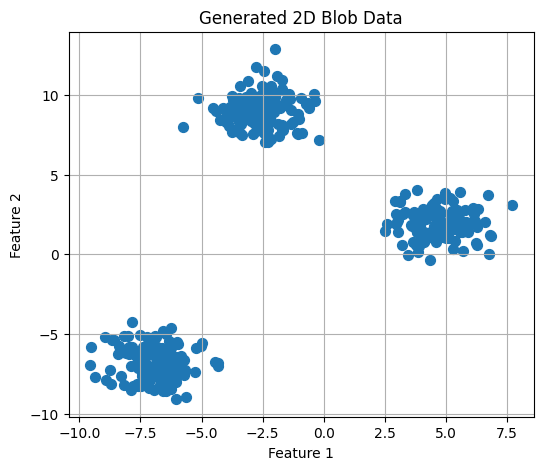

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


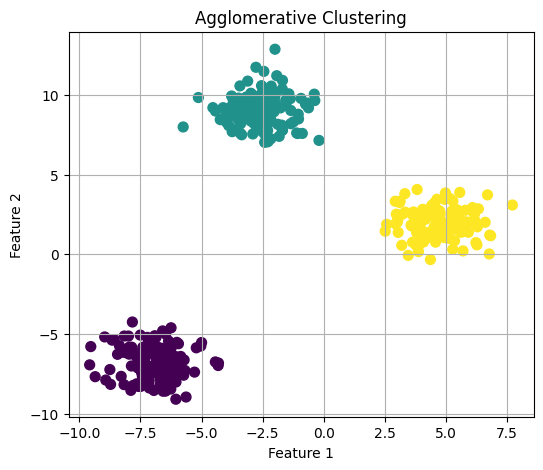

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

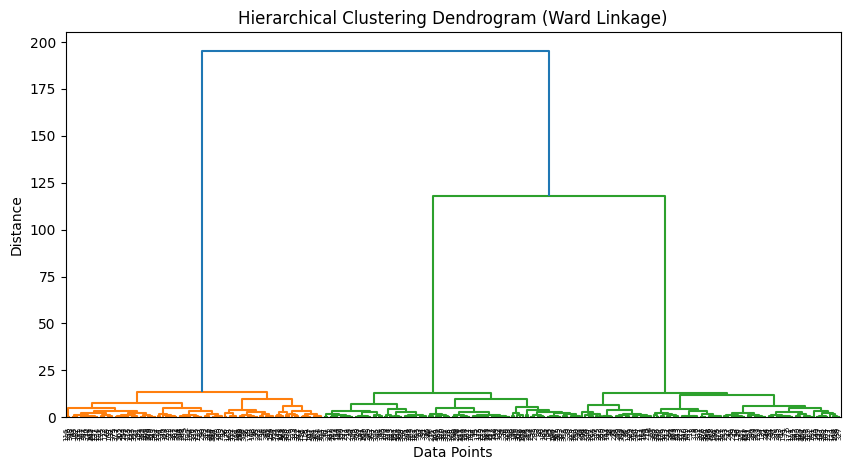

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. Load the dataset
# =====================================================================
# Read the CSV file into a Pandas DataFrame
df = pd.read_csv('CC GENERAL.csv')

# =====================================================================
# 2. Identify numeric vs categorical features
# =====================================================================
# df.info() provides a concise summary of the dataframe including column data types and non-null counts
print("--- Data Info (Numeric vs Categorical) ---")
df.info()

# We can also dynamically extract categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n--- Categorical Features ---")
print(categorical_cols.tolist())









--- Data Info (Numeric vs Categorical) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX          

In [3]:
# =====================================================================
# 3. Check counts of categories for categorical features
# =====================================================================
# In this dataset, 'CUST_ID' is the only categorical feature.
# We check how many unique values it has to understand its cardinality.
for col in categorical_cols:
    print(f"\nFeature: {col}, Unique Values: {df[col].nunique()}")

# =====================================================================
# 4. Identify missing or unknown values
# =====================================================================
# df.isnull().sum() counts the number of missing (NaN) values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())


Feature: CUST_ID, Unique Values: 8950

--- Missing Values ---
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [4]:
# =====================================================================
# 5. Check distributions of numeric features (min, max, mean, std, skewness)
# =====================================================================
print("\n--- Numeric Distributions ---")
# df.describe() computes standard summary statistics for numeric columns
desc = df.describe().T

# We calculate skewness separately because it is highly relevant for clustering algorithms
# Skewness tells us if the data is symmetrical or skewed to one side (high outliers)
desc['skewness'] = df.select_dtypes(include=[np.number]).skew()

# Displaying only the requested statistics for clarity
print(desc[['mean', 'std', 'min', 'max', 'skewness']])


--- Numeric Distributions ---
                                         mean          std        min  \
BALANCE                           1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                    0.877271     0.236904   0.000000   
PURCHASES                         1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES             411.067645   904.338115   0.000000   
CASH_ADVANCE                       978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY                  0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY           0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY               0.135144     0.200121   0.000000   
CASH_ADVANCE_TRX                     3.248827     6.824647   0.000000   
PURCHASES_TRX                       14.709832    24.857649   0.000000   
CREDIT_LIMIT        

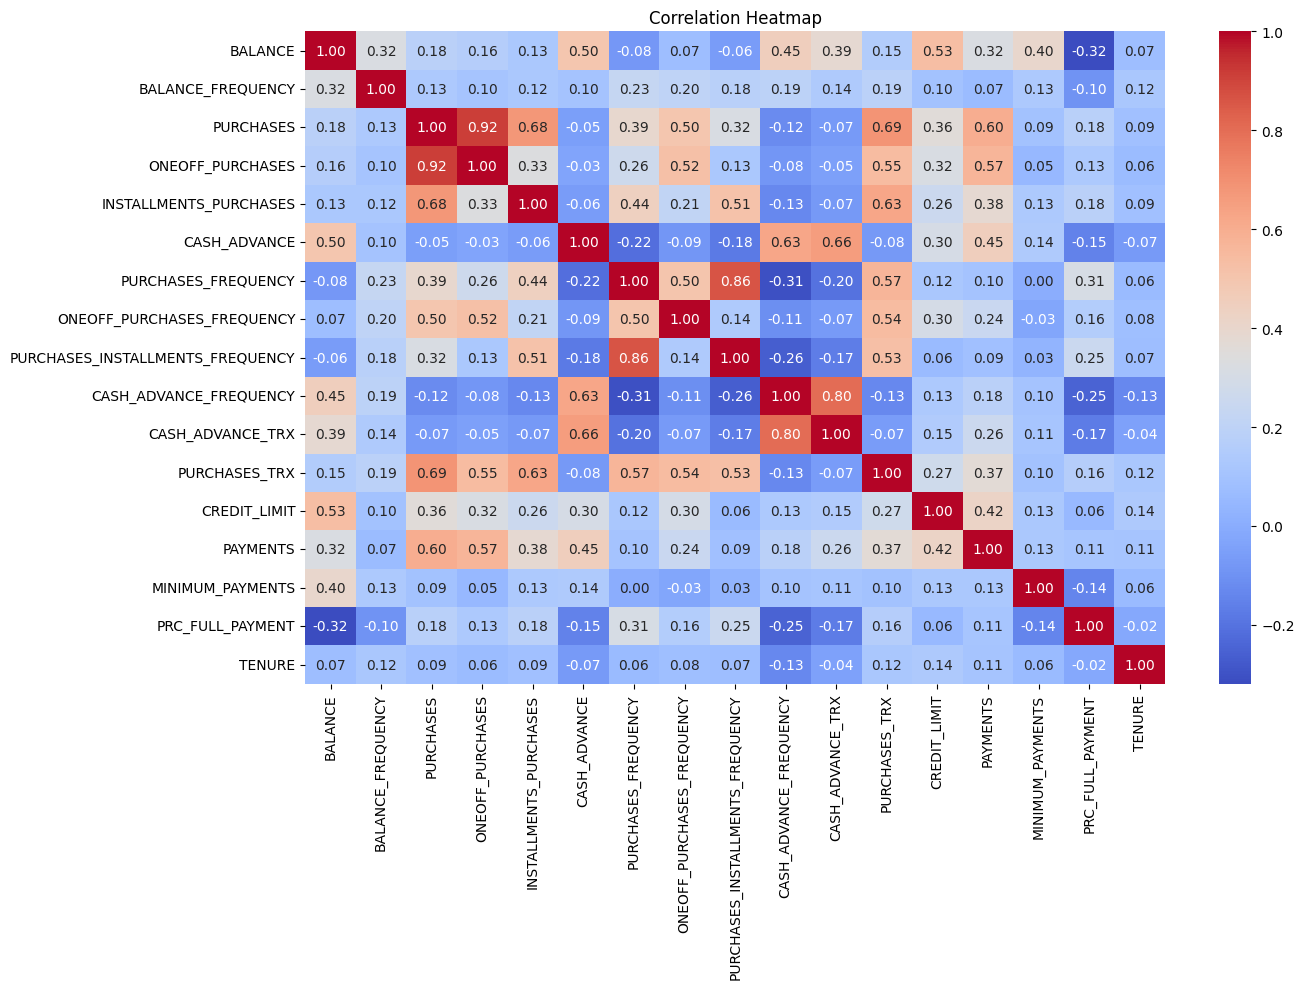

In [5]:
# =====================================================================
# 6. Look for correlations between numeric features
# =====================================================================
# Calculate the Pearson correlation matrix (dropping CUST_ID as it is non-numeric)
corr_matrix = df.drop(columns=['CUST_ID']).corr()

# Plotting the correlation heatmap
plt.figure(figsize=(14, 10))
# annot=True displays the actual correlation values inside the squares
# cmap='coolwarm' uses blue for negative correlation and red for positive correlation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show() # Use plt.savefig('heatmap.png') if you want to save it to a file instead

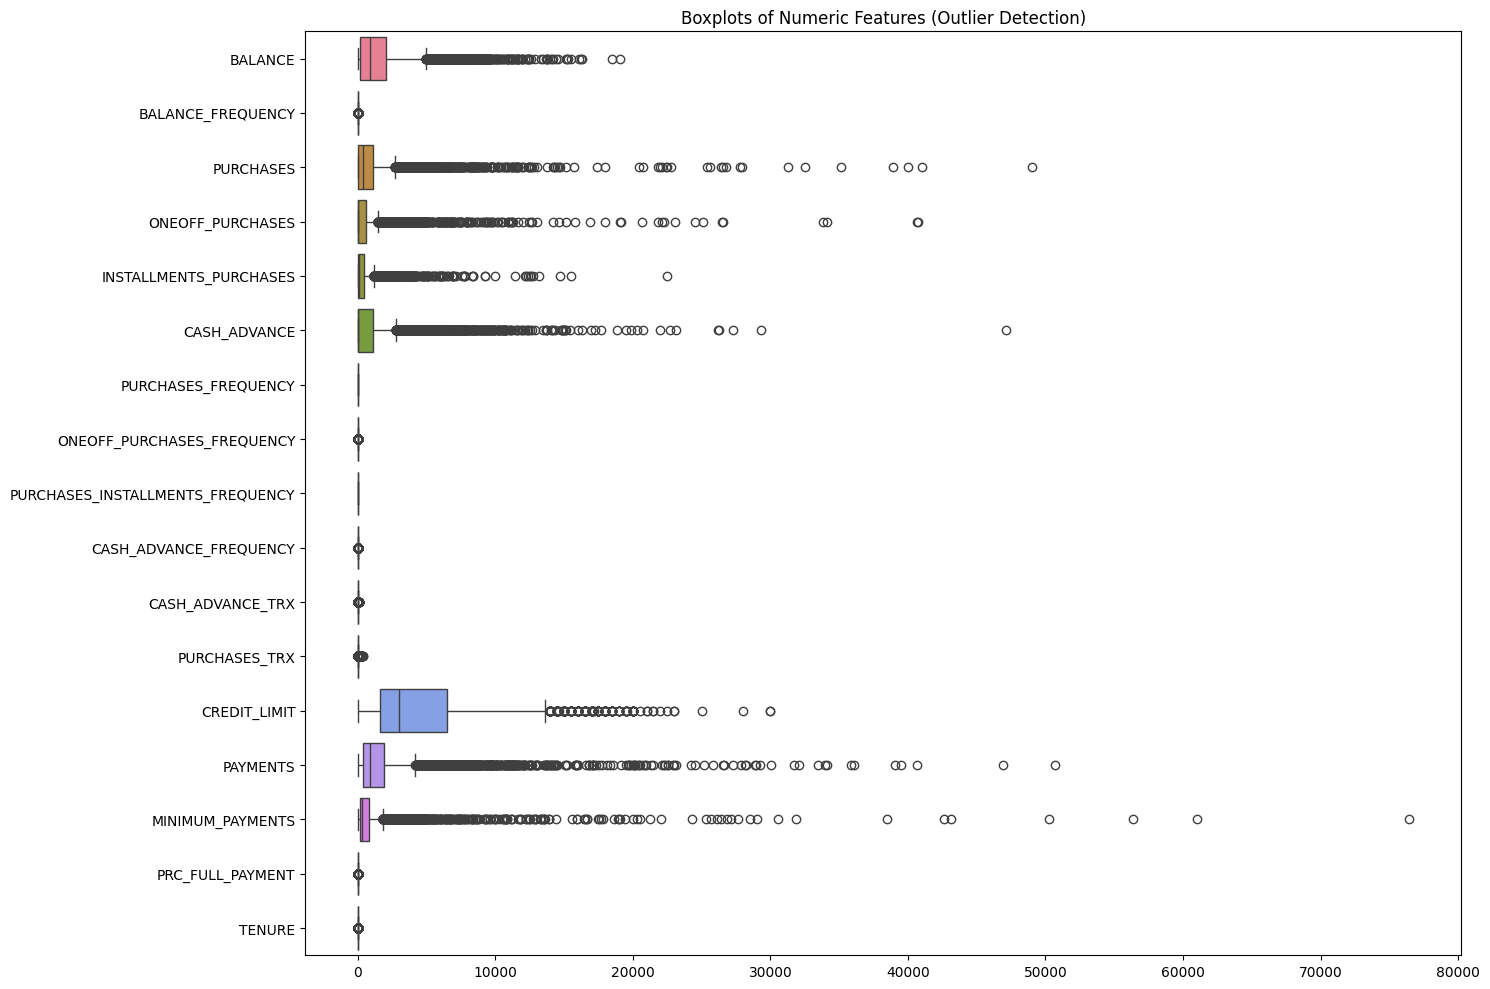

In [6]:
# =====================================================================
# 7. Identify outliers that may affect clustering
# =====================================================================
# We use boxplots to visualize the distribution and outliers of each numeric feature
plt.figure(figsize=(15, 10))

# orient='h' plots the boxes horizontally to make the long feature names readable
# We drop CUST_ID again to only plot numeric values
sns.boxplot(data=df.drop(columns=['CUST_ID']), orient='h')
plt.title('Boxplots of Numeric Features (Outlier Detection)')
plt.tight_layout()
plt.show() # Use plt.savefig('boxplots.png') if you want to save it to a file instead

## **2. Data Preparation**

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. Load the dataset
# =====================================================================
df = pd.read_csv('CC GENERAL.csv')

# =====================================================================
# 2. Drop irrelevant columns
# =====================================================================
# We drop CUST_ID because it's an arbitrary string identifier. 
# It provides no behavioral pattern and will ruin distance calculations.
df_prep = df.drop(columns=['CUST_ID'])






In [8]:
# =====================================================================
# 3. Handle missing values
# =====================================================================
# We use the median to fill missing values instead of the mean because 
# EDA showed extreme right-skewness (huge outliers). 
# The median is robust against extreme outliers.
median_min_payments = df_prep['MINIMUM_PAYMENTS'].median()
df_prep['MINIMUM_PAYMENTS'] = df_prep['MINIMUM_PAYMENTS'].fillna(median_min_payments)

median_credit_limit = df_prep['CREDIT_LIMIT'].median()
df_prep['CREDIT_LIMIT'] = df_prep['CREDIT_LIMIT'].fillna(median_credit_limit)


In [9]:
# =====================================================================
# 4. Handle Skewness (Log Transformation)
# =====================================================================
# Because the financial data is extremely skewed, algorithms like Agglomerative 
#  will struggle. A Log Transformation heavily reduces the impact of 
# extreme outliers. We use np.log(1 + x) instead of np.log(x) because our data 
# contains zeros, and log(0) is undefined (infinity).
df_log = np.log(1 + df_prep)

# =====================================================================
# 5. Scale numeric features
# =====================================================================
# StandardScaler ensures that all features have a mean of 0 and standard deviation of 1.
# This makes features with small decimal ranges (like frequency) exactly as 
# important as features with large monetary ranges (like Balance).
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_log)

# Convert the scaled array back into a pandas DataFrame for easier viewing/handling
df_scaled = pd.DataFrame(df_scaled_array, columns=df_log.columns)

In [10]:
# =====================================================================
# 6. Verification
# =====================================================================
print("--- Final Dataset Verification ---")
# Check that there are absolutely no missing values left
print(f"Total Missing Values: {df_scaled.isnull().sum().sum()}") 

# Check that every single column is numeric (float64)
print(f"\nData Types:\n{df_scaled.dtypes.unique()}") 

# Check the final shape to ensure we still have all 8950 rows and our 17 features
print(f"\nShape of prepared data: {df_scaled.shape}")

--- Final Dataset Verification ---
Total Missing Values: 0

Data Types:
[dtype('float64')]

Shape of prepared data: (8950, 17)


## **3. Apply Agglomerative Clustering**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc


# Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)


# =====================================================================
# STEP 3.1: Initial "Random" Agglomerative Clustering
# =====================================================================
print("--- Running Initial Random Agglomerative Clustering ---")
# We blindly guess a number of clusters (e.g., 10) to see what happens 
# before using any mathematical logic.
initial_k = 10
# 1. Apply Agglomerative Clustering
# We use 'ward' linkage and 'euclidean' metric because they work best 
# together to create compact, well-separated spherical clusters.
agg_init = AgglomerativeClustering(n_clusters=initial_k, metric='euclidean', linkage='ward')
labels_init = agg_init.fit_predict(df_scaled)
sil_init = silhouette_score(df_scaled, labels_init)











--- Running Initial Random Agglomerative Clustering ---


## **4. Visualize the Clustering Results**

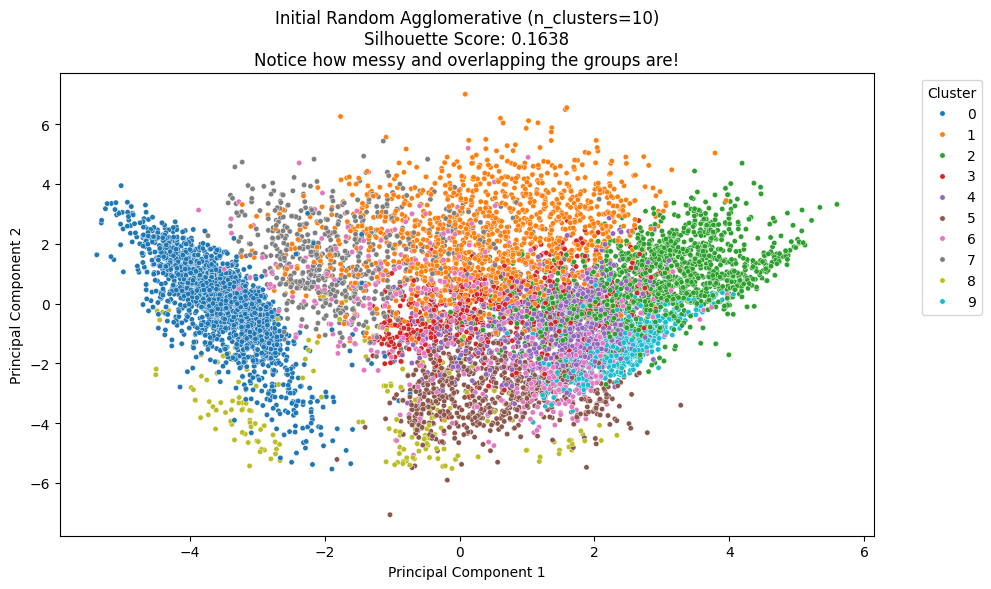

In [12]:
# Visualize Initial Random Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_result[:, 0], 
    y=pca_result[:, 1], 
    hue=labels_init, 
    palette='tab10', 
    s=15, 
    legend='full'
)
plt.title(f'Initial Random Agglomerative (n_clusters={initial_k})\nSilhouette Score: {sil_init:.4f}\nNotice how messy and overlapping the groups are!')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


--- Generating Dendrogram (This might take a moment) ---


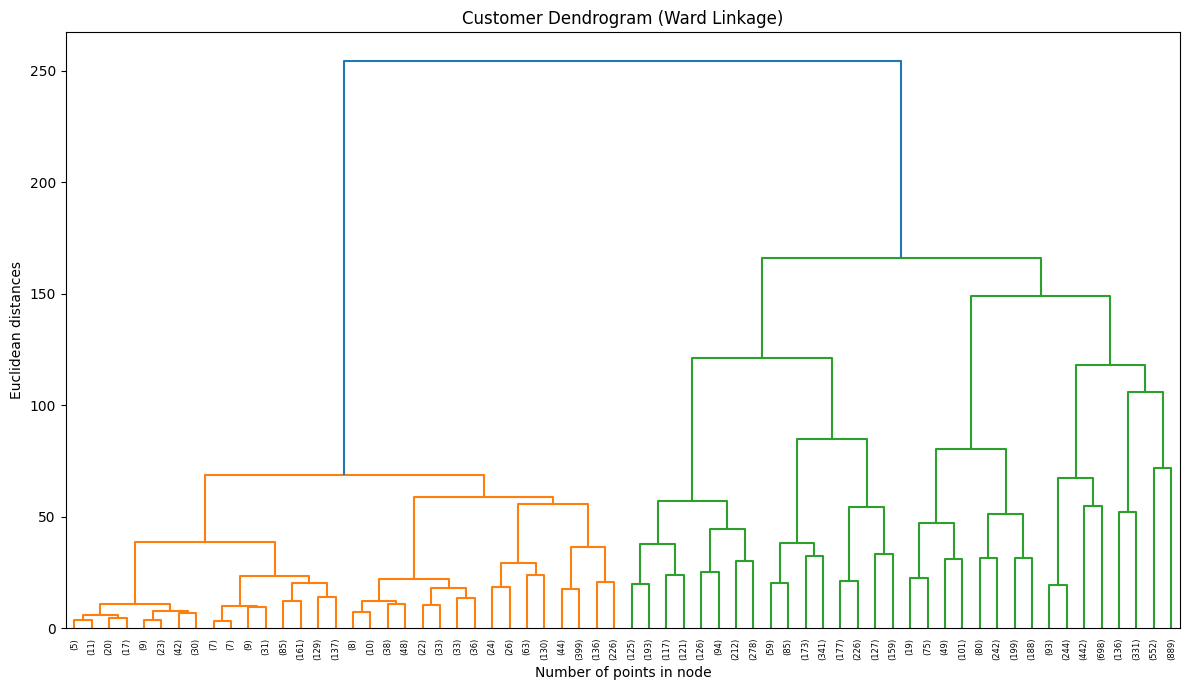

In [13]:
# =====================================================================
# STEP 3.2: Plotting the Dendrogram (Finding the logic)
# =====================================================================
print("\n--- Generating Dendrogram (This might take a moment) ---")
plt.figure(figsize=(12, 7))
plt.title("Customer Dendrogram (Ward Linkage)")

# We use the Dendrogram to mathematically find the best 'n_clusters' ranges
# We use 'ward' linkage which minimizes the variance of clusters being merged.
# truncate_mode='level' ensures we only see the top 5 levels of splits, 
# otherwise 8950 points would look like a giant black blob at the bottom.
dend = shc.dendrogram(shc.linkage(df_scaled, method='ward'), truncate_mode='level', p=5)

plt.xlabel("Number of points in node")
plt.ylabel("Euclidean distances")
plt.tight_layout()
plt.show() 


--- Generating Dendrogram (This might take a moment) ---


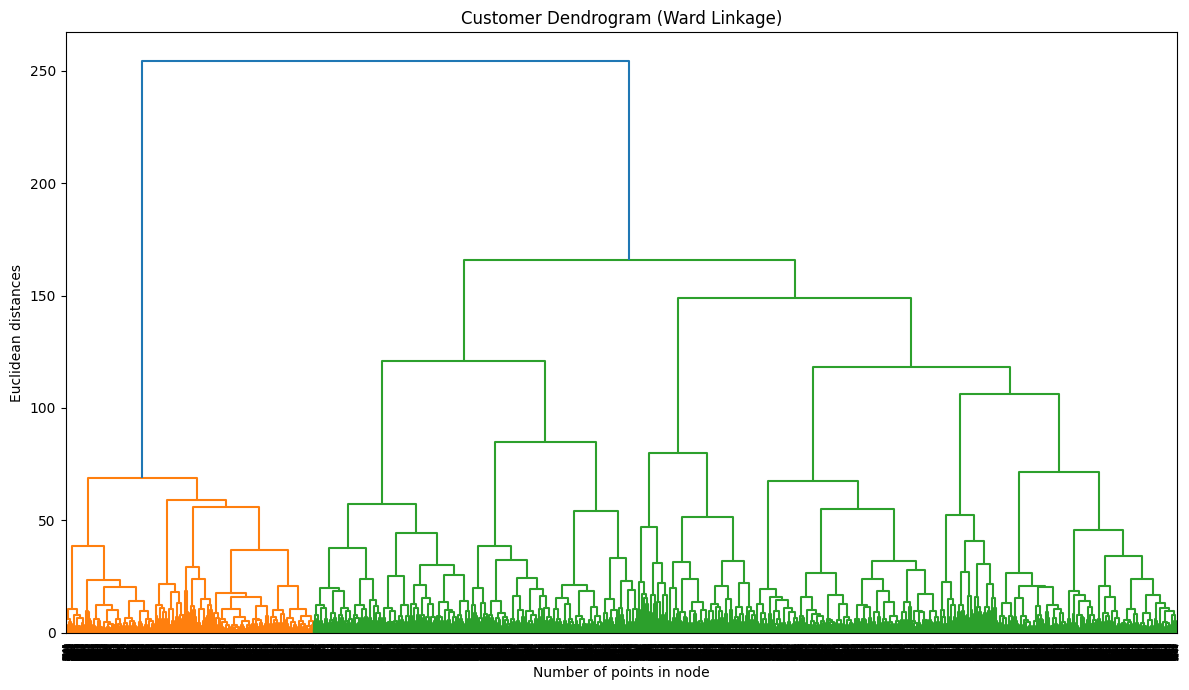

In [16]:
# =====================================================================
# STEP 3.2: Plotting the Dendrogram (Finding the logic)
# =====================================================================
print("\n--- Generating Dendrogram (This might take a moment) ---")
plt.figure(figsize=(12, 7))
plt.title("Customer Dendrogram (Ward Linkage)")

# We use the Dendrogram to mathematically find the best 'n_clusters' ranges
# We use 'ward' linkage which minimizes the variance of clusters being merged.
dend = shc.dendrogram(shc.linkage(df_scaled, method='ward'))

plt.xlabel("Number of points in node")
plt.ylabel("Euclidean distances")
plt.tight_layout()
plt.show() 

## **5. Evaluate the Clustering**


--- Evaluating Logical n_clusters Range ---
n_clusters = 2 | Silhouette Score: 0.2271


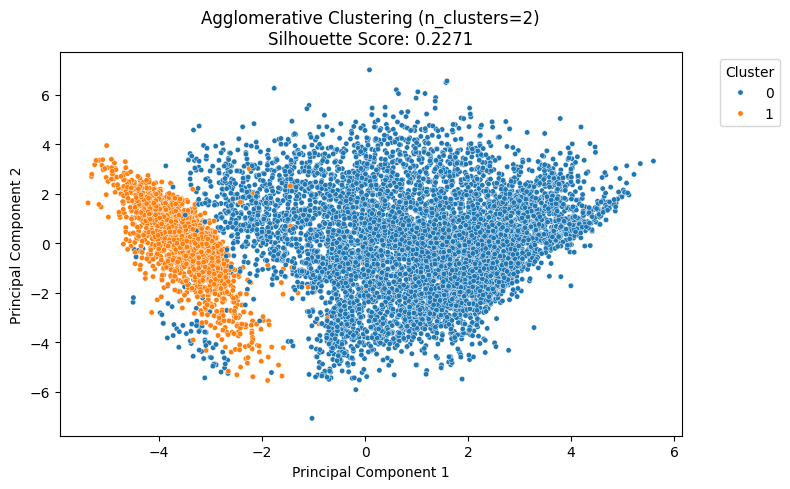

n_clusters = 3 | Silhouette Score: 0.1661


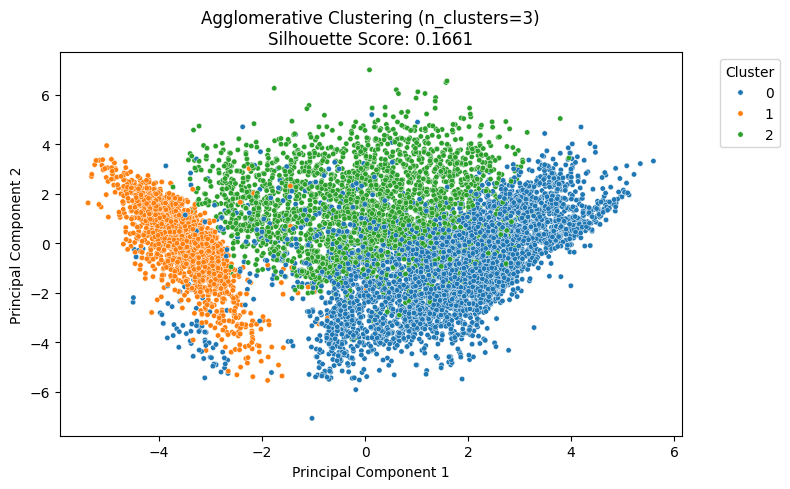

n_clusters = 4 | Silhouette Score: 0.1760


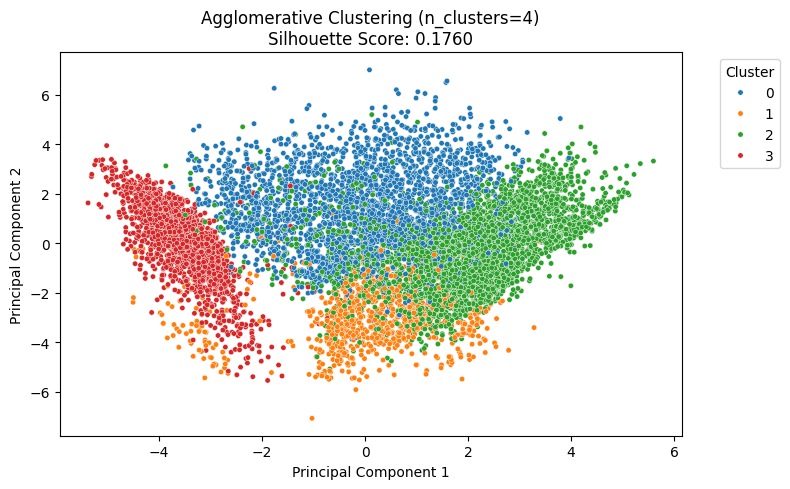

n_clusters = 5 | Silhouette Score: 0.1795


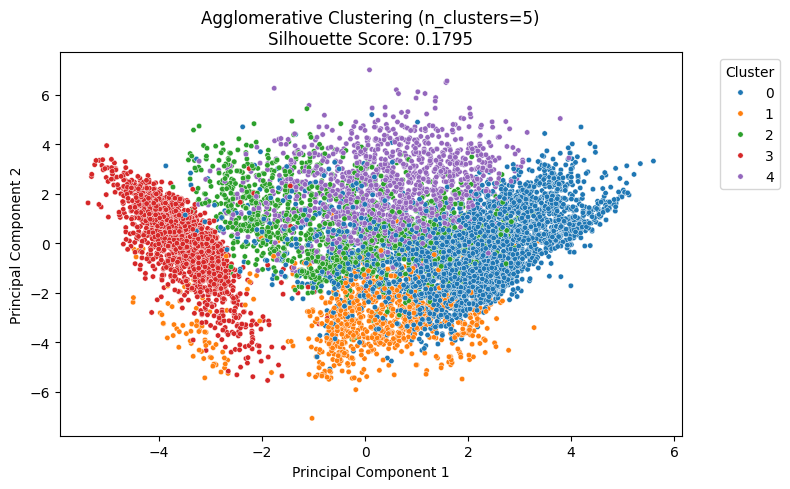

n_clusters = 6 | Silhouette Score: 0.1762


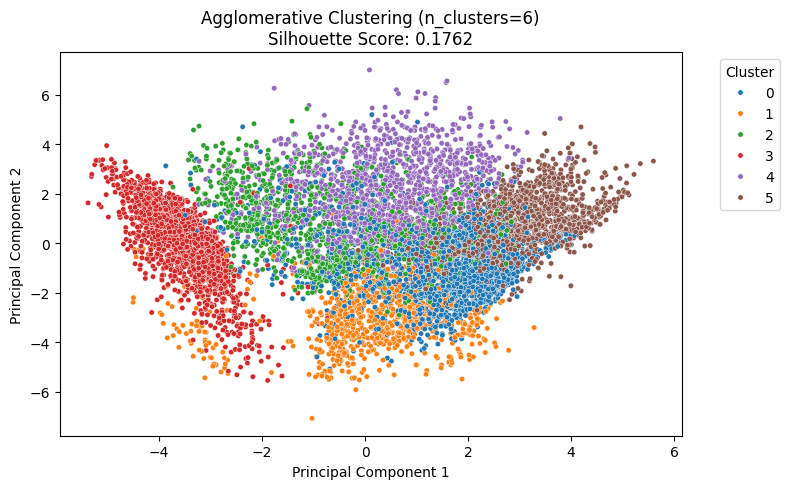

In [14]:
# =====================================================================
# STEP 5 & 6: Evaluate Range, Visualize, and Justify
# =====================================================================
# Based on the Dendrogram's longest vertical branches, the most logical 
# splits occur between 2 and 6 clusters.
n_clusters_range = range(2, 7) # This will test 2, 3, 4, 5, and 6

results = []
print("\n--- Evaluating Logical n_clusters Range ---")

for k in n_clusters_range:
    # Apply Agglomerative Clustering
    # We use 'ward' linkage and 'euclidean' metric because they work best 
    # together to create compact, well-separated spherical clusters.
    agg_model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg_model.fit_predict(df_scaled)
    
    # Evaluate using Silhouette Score
    sil_score = silhouette_score(df_scaled, labels)
    results.append({'n_clusters': k, 'silhouette_score': sil_score})
    
    print(f"n_clusters = {k} | Silhouette Score: {sil_score:.4f}")
    
    # Visualize the clustering
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        x=pca_result[:, 0], 
        y=pca_result[:, 1], 
        hue=labels, 
        palette='tab10', 
        s=15, 
        legend='full'
    )
    plt.title(f'Agglomerative Clustering (n_clusters={k})\nSilhouette Score: {sil_score:.4f}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [15]:
# Final Conclusion Printout
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['silhouette_score'].idxmax()]['n_clusters']

print("\n=======================================================")
print(f"FINAL CONCLUSION: Based on Silhouette Scores and visual clarity,")
print(f"the optimal n_clusters is: {int(best_k)}")
print("=======================================================")


FINAL CONCLUSION: Based on Silhouette Scores and visual clarity,
the optimal n_clusters is: 2


## **6. Explain whether the clustering quality and justify your reasoning**

1. Assessment of Clustering Quality: Fair / Moderate
The overall clustering quality is fair. It is not perfectly separated, but it successfully captures meaningful mathematical patterns in the data. The optimal number of clusters chosen was n_clusters = 2, which achieved the highest Silhouette Score of 0.2271.

2. Justification and Reasoning:

    A. Interpretation of the Silhouette Score:
The Silhouette Score ranges from -1 to 1. A score of 0.2271 is greater than 0, which means the clusters are valid and the data points are generally closer to their own cluster than to the neighboring cluster. However, because the score is relatively close to 0, it mathematically indicates that there is a significant amount of overlapping at the boundaries of the clusters.

    B. The Nature of the Dataset (Continuous Human Behavior):
Credit card usage data does not naturally form perfectly isolated "islands" of behavior. While we have extreme cases (e.g., people who only use cash advances vs. people who only make one-off purchases), the vast majority of customers display a mix of behaviors. This continuous spectrum of spending means the boundary between Cluster 1 and Cluster 2 will naturally be blurred, which directly explains why the Silhouette Score is modest rather than close to 1.0.

    C. Comparison with Other Configurations:
When we tested n_clusters from 3 to 6, the Silhouette Scores dropped to the ~0.16 - 0.17 range. When we guessed a random configuration (n_clusters = 10), the score dropped to ~0.15. This justifies our choice of n_clusters = 2. It proves that forcing the algorithm to find more than 2 groups just arbitrarily chops a continuous dataset into messy fragments, whereas 2 groups capture the highest-level, most reliable variance in the data.

    D. Algorithm Suitability:
We used Ward linkage with the Euclidean metric. Ward's method is designed to minimize the variance within each cluster, creating spherical, compact groups. Given the extreme outliers we saw in the EDA, Ward linkage combined with our Log Transformation successfully prevented the algorithm from making 1-person clusters (which single linkage might have done) and forced it to find the two most balanced, generalized customer profiles.